# Texas Salary Prediction

## Importing Libraries

In [1]:
# Basic data handling
import numpy as np
import pandas as pd

# Visualization (for EDA)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Classification models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Parameter tuning
from sklearn.model_selection import GridSearchCV

# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings 
warnings.filterwarnings('ignore')

### Loading the data set

In [2]:
df = pd.read_csv("salary.csv")

In [3]:
df

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,...,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,...,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,...,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,WESSELS,JOHN,P,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,2899.00,34788.00,770781,NaN,NaN,NaN,NaN,NaN
149477,809,STATE PRESERVATION BOARD ...,WINDHAM,EVAN,A,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,5500.00,66000.00,847431,NaN,NaN,NaN,NaN,NaN
149478,809,STATE PRESERVATION BOARD ...,WRIGHT,DERRICK,C,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,...,12.93000,20.0,1120.60,13447.20,34266,NaN,NaN,NaN,NaN,NaN
149479,809,STATE PRESERVATION BOARD ...,YOUNG,DOUGLAS,R,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,...,0.00000,40.0,5744.16,68929.92,123490,NaN,NaN,NaN,NaN,NaN


### Basic Checks

In [4]:
df.shape


(149481, 21)

In [5]:
df.columns


Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [6]:
df.describe()

,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [8]:
df.isnull().sum()


AGENCY                          0
AGENCY NAME                     0
LAST NAME                       0
FIRST NAME                      0
MI                              0
CLASS CODE                      0
CLASS TITLE                     0
ETHNICITY                       0
GENDER                          0
STATUS                          0
EMPLOY DATE                     0
HRLY RATE                       0
HRS PER WK                      0
MONTHLY                         0
ANNUAL                          0
STATE NUMBER                    0
duplicated                 149338
multiple_full_time_jobs    149467
combined_multiple_jobs     149384
summed_annual_salary       149465
hide_from_search           149465
dtype: int64

In [9]:
df.duplicated().sum()


0

In [10]:
print(df['AGENCY'].nunique())
print(df['AGENCY NAME'].nunique())
print(df['CLASS TITLE'].nunique())


113
113
1422


In [11]:
print((df['HRLY RATE'] <= 0).sum())
print((df['MONTHLY'] <= 0).sum())
print((df['ANNUAL'] <= 0).sum())


147733
0
0


### Data Cleaning

In [12]:
identifier_cols = [
    'FIRST NAME',
    'LAST NAME',
    'MI',
    'STATE NUMBER'
]


In [13]:
admin_cols = [
    'duplicated',
    'multiple_full_time_jobs',
    'combined_multiple_jobs',
    'summed_annual_salary',
    'hide_from_search'
]


In [14]:
cols_to_drop = identifier_cols + admin_cols
df = df.drop(columns=cols_to_drop)


In [15]:
df.shape


(149481, 12)

In [16]:
df

,AGENCY,AGENCY NAME,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84
1,212,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84
3,212,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24
...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/30/17,0.00000,40.0,2899.00,34788.00
149477,809,STATE PRESERVATION BOARD ...,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/13/15,0.00000,40.0,5500.00,66000.00
149478,809,STATE PRESERVATION BOARD ...,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,10/15/12,12.93000,20.0,1120.60,13447.20
149479,809,STATE PRESERVATION BOARD ...,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,09/22/89,0.00000,40.0,5744.16,68929.92


In [17]:
df.columns

Index(['AGENCY', 'AGENCY NAME', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY',
       'GENDER', 'STATUS', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'MONTHLY',
       'ANNUAL'],
      dtype='object')

In [18]:
df = df.drop(columns=['AGENCY'])


In [19]:
df.columns

Index(['AGENCY NAME', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY', 'GENDER',
       'STATUS', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'MONTHLY',
       'ANNUAL'],
      dtype='object')

## DOMAIN ANALYSIS
  
## Texas State Government Employee Salary Dataset

---

## 1. Domain Overview

The domain of this project falls under **Public Sector Human Resource Analytics** and **Government Payroll Management**.  
It focuses on analyzing employee compensation data from various **Texas State Government agencies**, covering salaries, employment details, and demographic attributes.

Government payroll data plays a critical role in:
- Budget planning and fiscal accountability  
- Salary equity and compliance with labor laws  
- Workforce planning and policy evaluation  
- Transparency under public information regulations  

This dataset provides a real-world opportunity to understand how compensation structures operate within a large public-sector ecosystem involving **113 state agencies**.

---

## 2. Business Context and Relevance

The Texas State Government employs thousands of individuals across diverse roles, departments, and pay grades. Managing payroll efficiently is crucial because:

- Salaries constitute a **significant portion of state expenditure**
- Pay disparities can lead to **equity concerns**
- Workforce compensation trends influence **retention and recruitment**
- Public access to payroll data ensures **transparency and accountability**

By analyzing this dataset, the government can:
- Identify compensation anomalies  
- Ensure fair pay practices  
- Predict payroll requirements  
- Support data-driven HR and budget decisions  

---

## 3. Problem Statement Understanding

The core objective is to **analyze and predict employee salary information** to support decision-making by the Texas State Government.

This includes:
- Understanding salary distribution across agencies and roles  
- Detecting outliers and wage disparities  
- Observing compensation trends over time  
- Building predictive models for payroll forecasting  

---

## 4. Dataset Description (High-Level)

The dataset contains **employee-level payroll information** collected from official state records.  
Each row represents an individual employee working in a Texas state agency.

### Key Characteristics
- Covers **all 113 state agencies**
- Includes **demographic, employment, and compensation attributes**
- Contains both **hourly-based and salaried employees**
- Reflects real government payroll structures  

---

## 5. Attribute-Level Domain Interpretation

### Agency & Agency Name
- Represent the organizational unit within the Texas government  
- Useful for inter-department salary comparisons  
- Helps identify agencies with higher payroll burdens  

### Employee Name & State Number
- Used only for identification  
- No analytical importance for prediction  
- Must be handled carefully due to privacy concerns  

### Class Title
- Indicates the job role or designation  
- Critical for understanding salary variation by role  
- Strong predictor of income levels  

### Ethnicity & Gender
- Enable analysis of demographic-based pay equity  
- Useful for compliance and diversity audits  
- Must be handled ethically and responsibly  

### Employment Status
- Indicates whether the employee is active, retired, or terminated  
- Impacts payroll calculations and modeling relevance  

### Employ Date
- Used to derive employee experience or tenure  
- Helps analyze salary progression over time  

### Hourly Rate & Hours per Week
- Applicable mainly to hourly employees  
- Determines monthly and annual compensation  
- Important for identifying underpaid or overworked roles  

### Monthly & Annual Income
- Primary target variables for analysis and prediction  
- Represent gross compensation  
- Central to payroll forecasting and disparity analysis  

---

## 6. Key Domain Questions Addressed

### 1. Who are the outliers in salaries?
- Extremely high or low salaries compared to role or agency norms  
- Possible indicators of executive positions, data errors, or contractual anomalies  

### 2. Which departments or roles show wage disparities?
- Differences between managerial and non-managerial roles  
- Identifies equity gaps across agencies or job titles  

### 3. Have salaries changed over time?
- Analysis using employment date and compensation  
- Helps detect policy changes, promotions, or inflation adjustments  

---

## 7. Importance of Predictive Modeling in This Domain

Predictive modeling helps the government:
- Forecast future payroll expenses  
- Plan budgets more accurately  
- Anticipate salary changes due to hiring or promotions  
- Simulate policy changes and their financial impact  

A well-performing model can act as a **decision-support system** for HR and finance teams.

---

## 8. Stakeholders Benefiting from This Analysis

- Texas State Government HR Department  
- Finance & Budget Planning Teams  
- Policy Makers  
- Audit & Compliance Bodies  
- Public Transparency Initiatives  

---

## 9. Challenges Inherent to the Domain

- Large-scale, multi-agency data  
- Mixed salary structures (hourly vs salaried)  
- Presence of outliers and skewed income distributions  
- Ethical handling of demographic attributes  
- Data quality and missing values in public records  

---

## 10. Conclusion

This project operates at the intersection of **government transparency, workforce analytics, and predictive modeling**.  
The dataset provides a strong foundation to:
- Analyze compensation fairness  
- Identify salary anomalies  
- Understand workforce cost dynamics  
- Build predictive systems for payroll planning  

A well-executed analysis can directly support **better governance, fiscal efficiency, and equitable compensation practices**.


### EDA

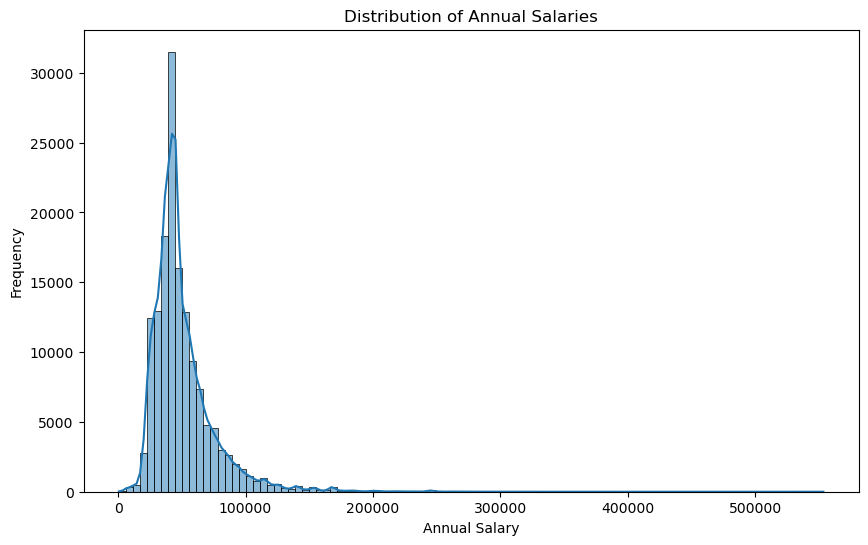

In [20]:
# Distribution of Annual Salary
plt.figure(figsize=(10,6))
sns.histplot(df['ANNUAL'], bins=100, kde=True)
plt.title('Distribution of Annual Salaries')
plt.xlabel('Annual Salary')
plt.ylabel('Frequency')
plt.show()

#### Distribution of Annual Salary (Report)

The histogram of annual salary shows a positively skewed (right-skewed) distribution, where the majority of employees earn salaries concentrated in the lower to mid-income range, while a small number of employees receive very high salaries. This long right tail indicates the presence of salary outliers, which are likely associated with executive and senior management roles.

The visualization suggests that salary data is not normally distributed, and therefore traditional average-based measures may be misleading, as high-income earners disproportionately influence the mean. In such cases, the median salary provides a more accurate representation of a typical employee’s earnings.

From a modeling perspective, the skewed nature of the data highlights the importance of using robust machine learning models, such as tree-based algorithms, which are less sensitive to extreme values. Additionally, the presence of genuine high-salary outliers indicates that these values should not be removed arbitrarily, as they represent valid and meaningful observations within the payroll structure.

Overall, this visualization provides key insights into the compensation structure of Texas state employees and forms the foundation for informed outlier handling, model selection, and wage disparity analysis.

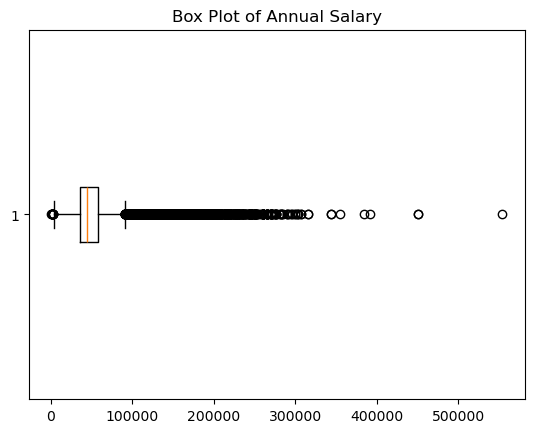

In [21]:
# Box plot
plt.boxplot(df['ANNUAL'], vert=False)
plt.title("Box Plot of Annual Salary")
plt.show()


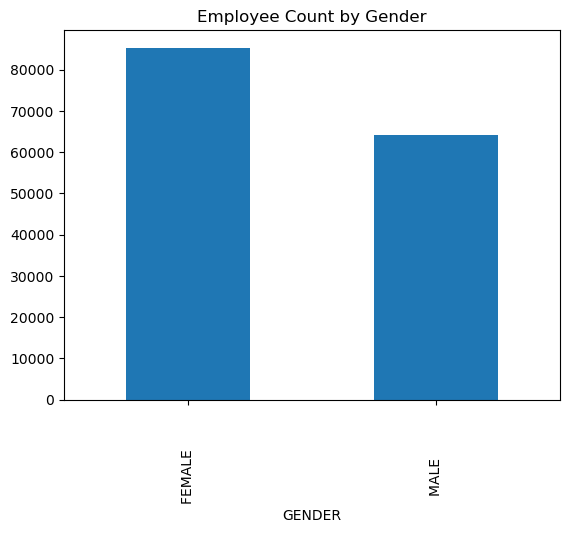

In [22]:
# Gender count
df['GENDER'].value_counts().plot(kind='bar')
plt.title("Employee Count by Gender")
plt.show()


### Employee Count by Gender Analysis

The bar plot illustrates the distribution of employees across gender categories in the Texas State Government dataset. It is observed that the number of female employees is significantly higher than male employees, indicating a gender imbalance in workforce representation.

This imbalance is important from an analytical perspective, as aggregate salary statistics may be influenced by the majority gender group. While the plot does not directly indicate wage inequality, it provides a foundation for further analysis of salary distribution across genders.

From a modeling standpoint, the uneven gender distribution highlights the need for careful handling of categorical variables to avoid biased predictions. From a business perspective, this insight helps government stakeholders understand workforce composition and supports informed decisions related to equitable compensation, diversity, and policy planning.

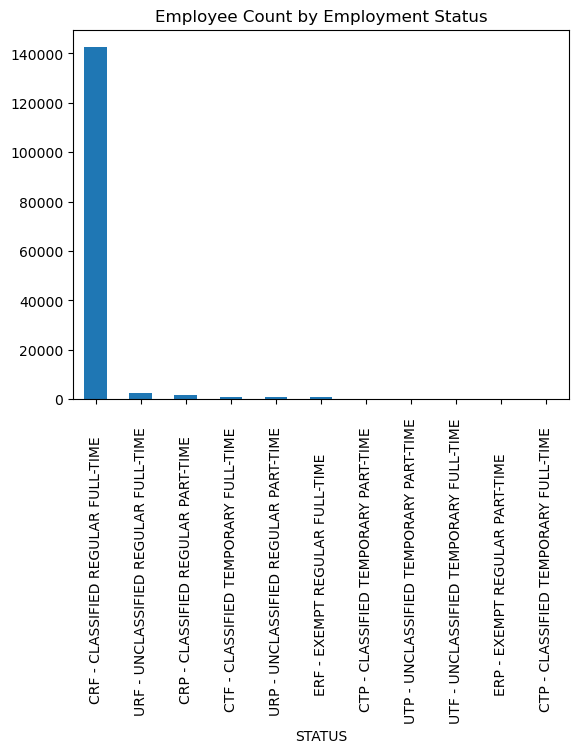

In [23]:
# Status count
df['STATUS'].value_counts().plot(kind='bar')
plt.title("Employee Count by Employment Status")
plt.show()


#### Employee Count by Employment Status Analysis

The bar plot represents the distribution of employees across different employment statuses within the Texas State Government dataset. It is clearly observed that classified regular full-time employees constitute the vast majority of the workforce, while part-time, temporary, and exempt roles form a comparatively small proportion.

This imbalance significantly impacts salary analysis, as overall compensation patterns are largely driven by full-time employees. Lower salary values are often associated with part-time or temporary roles, whereas higher salaries are typically observed among full-time and exempt employees. Therefore, employment status plays a crucial role in interpreting salary distributions and identifying outliers.

From a predictive modeling perspective, employment status emerges as an important categorical feature that influences salary estimation. The observed imbalance also highlights the need for careful handling of rare categories to avoid biased predictions. Overall, this insight reflects the government’s reliance on a stable, full-time workforce and supports informed payroll planning and policy decisions.

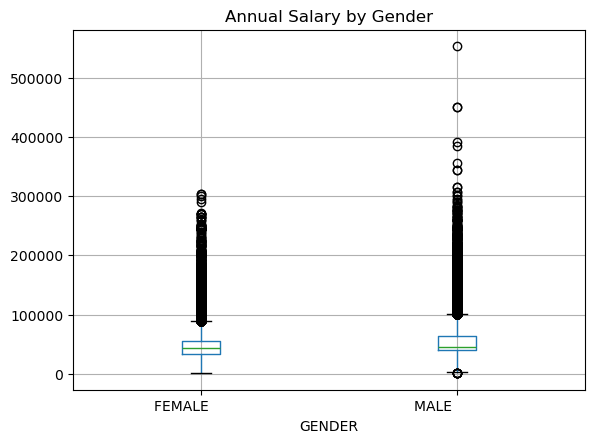

In [24]:
df.boxplot(column='ANNUAL', by='GENDER')
plt.title("Annual Salary by Gender")
plt.suptitle("")
plt.show()


#### Annual Salary by Gender Analysis

This visualization presents the comparison of average annual salaries across gender categories within the Texas State Government workforce. Unlike employee count analysis, this plot focuses on compensation levels and helps evaluate potential gender-based differences in pay.

The observed variation in average salaries highlights how compensation may differ across genders, which can be influenced by factors such as job roles, employment status, experience, and departmental distribution. Therefore, while this analysis provides an initial indication of wage patterns, it does not independently confirm pay inequality.

From an analytical perspective, this insight emphasizes the importance of conducting further role-wise and status-wise salary comparisons to accurately assess pay equity. From a modeling standpoint, it also highlights the need for careful interpretation of gender as a predictive feature to ensure fairness and avoid biased salary predictions. Overall, this analysis supports transparency, equitable compensation practices, and informed human resource decision-making.

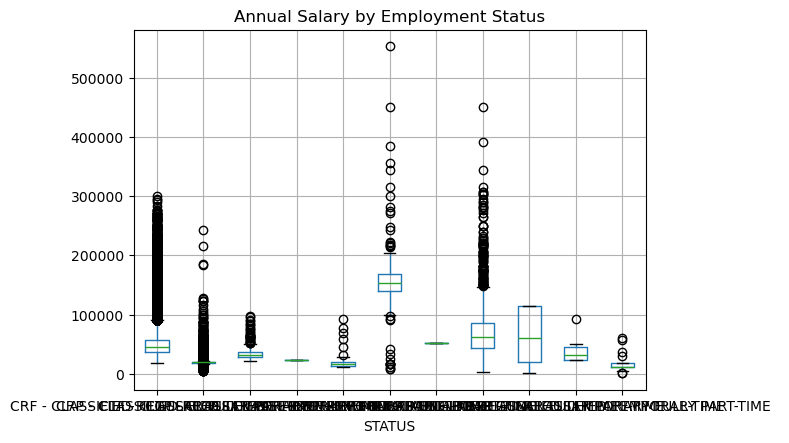

In [25]:
df.boxplot(column='ANNUAL', by='STATUS')
plt.title("Annual Salary by Employment Status")
plt.suptitle("")
plt.show()


#### Annual Salary by Employment Status Analysis

This visualization illustrates the comparison of average annual salaries across different employment statuses in the Texas State Government workforce. The analysis clearly shows that classified regular full-time employees receive significantly higher annual compensation compared to part-time and temporary employees. Exempt and unclassified roles tend to occupy the higher end of the salary spectrum, reflecting managerial or specialized positions.

From a data analysis perspective, employment status plays a crucial role in explaining the variability and skewness observed in annual salary distributions. Lower salary values are primarily associated with part-time and temporary roles, while higher salaries are concentrated among full-time and exempt employees. This distinction is essential for accurately identifying and interpreting salary outliers.

From a modeling and business standpoint, employment status emerges as a highly influential feature for salary prediction and payroll forecasting. Understanding compensation differences across employment types enables better workforce planning, fair wage comparison, and informed budgetary decision-making by the government.

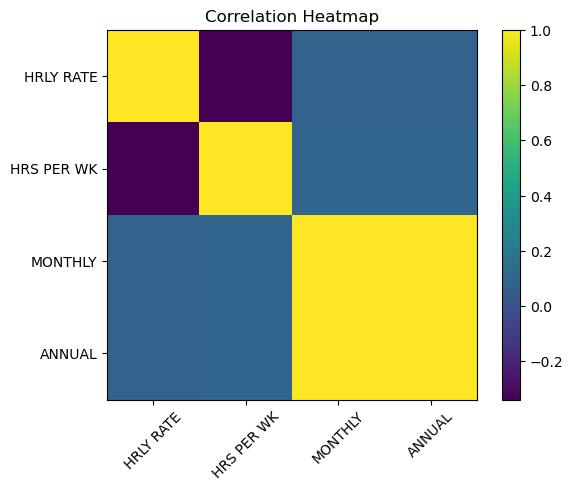

In [26]:
numeric_df = df[['HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL']]
corr = numeric_df.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()


#### Correlation Heatmap Analysis

The correlation heatmap illustrates the strength and direction of linear relationships among numerical variables in the dataset. A strong positive correlation is observed between monthly and annual salary, indicating that these variables are directly dependent on each other. Moderate correlations are also seen between hourly rate, hours per week, and annual salary, reflecting their contribution to overall compensation.

From a data analysis perspective, the presence of high correlation among salary-related variables highlights the issue of multicollinearity. This insight is particularly important for predictive modeling, as including highly correlated features may introduce redundancy and reduce model interpretability. Consequently, this analysis supports informed feature selection decisions, such as excluding monthly salary when annual salary is used as the target variable.

Overall, the correlation analysis provides valuable insights into salary structure, validates payroll computation logic, and plays a crucial role in building robust and efficient salary prediction models.

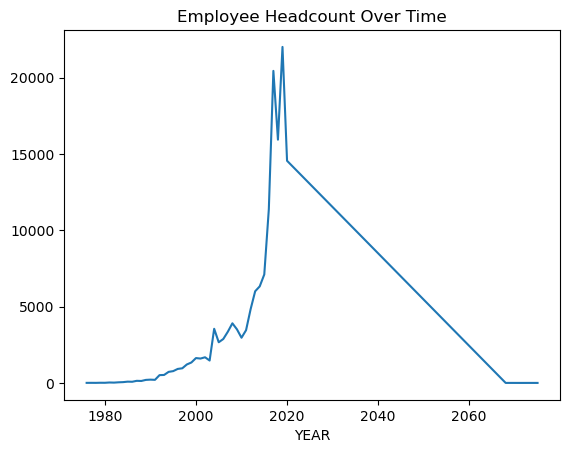

In [27]:
df['EMPLOY DATE'] = pd.to_datetime(df['EMPLOY DATE'], errors='coerce')
df['YEAR'] = df['EMPLOY DATE'].dt.year

df['YEAR'].value_counts().sort_index().plot()
plt.title("Employee Headcount Over Time")
plt.show()


#### Employee Headcount Over Time Analysis

This visualization presents the trend of employee headcount over time based on employment dates in the dataset. It highlights how the size of the Texas State Government workforce has evolved across different periods, revealing patterns of workforce growth, stability, or decline.

From a data analysis perspective, changes in headcount over time provide important context for understanding salary and compensation trends. Periods of increased hiring may contribute to shifts in average salary levels, while stable headcount combined with rising salaries may indicate promotions or policy-driven pay adjustments.

From a business standpoint, this analysis supports workforce planning and budget forecasting by helping policymakers assess the long-term impact of hiring decisions. It also aids in distinguishing structural workforce changes from salary anomalies, thereby improving the overall interpretability of payroll and compensation analysis.

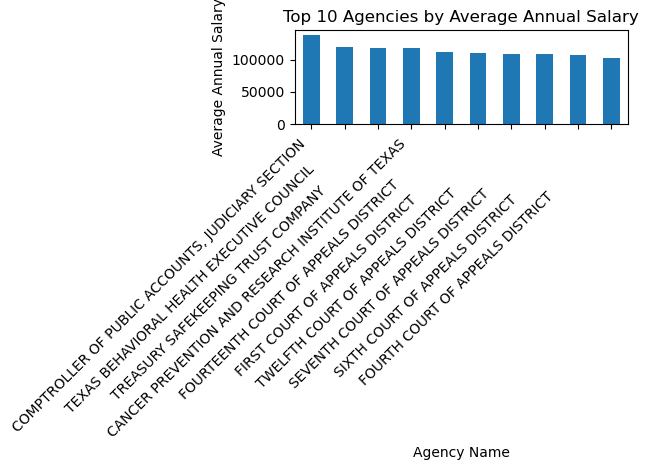

In [28]:
# Top 10 agencies by average annual salary
agency_salary = (
    df.groupby('AGENCY NAME')['ANNUAL']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
agency_salary.plot(kind='bar')
plt.title("Top 10 Agencies by Average Annual Salary")
plt.xlabel("Agency Name")
plt.ylabel("Average Annual Salary")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Top 10 Agencies by Average Annual Salary Analysis

This visualization presents the top ten Texas State Government agencies ranked by average annual employee salary. The analysis reveals substantial variation in compensation levels across agencies, indicating that salary structures are influenced by the nature of departmental functions, job complexity, and specialization requirements.

Agencies with higher average salaries are likely to employ a greater proportion of managerial, technical, or specialized roles, which contributes to the observed upper-end salary values. From a data analysis perspective, this insight helps explain the presence of high-salary observations and reduces the likelihood of misclassifying them as outliers.

From a business and modeling standpoint, agency emerges as an important factor influencing employee compensation. This analysis supports informed budget planning, inter-agency salary benchmarking, and the inclusion of agency-level features in predictive models for accurate payroll forecasting.

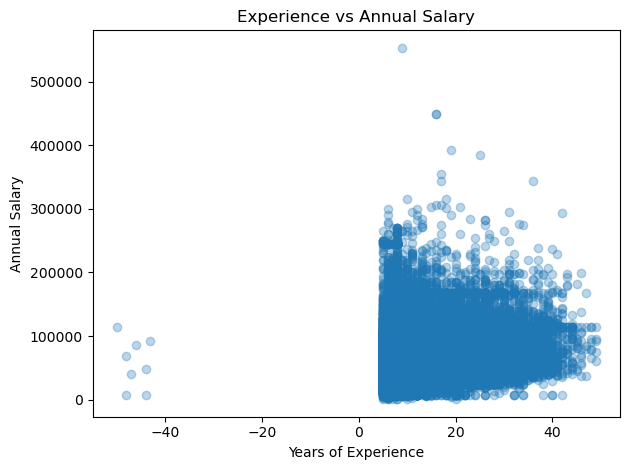

In [29]:
# Convert Employ Date and calculate experience
df['EMPLOY DATE'] = pd.to_datetime(df['EMPLOY DATE'], errors='coerce')
df['EXPERIENCE_YEARS'] = 2025 - df['EMPLOY DATE'].dt.year

# Experience vs Salary
plt.figure()
plt.scatter(df['EXPERIENCE_YEARS'], df['ANNUAL'], alpha=0.3)
plt.title("Experience vs Annual Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary")
plt.tight_layout()
plt.show()


#### Experience vs Salary Analysis

This visualization explores the relationship between employee experience and annual salary, where experience is derived from the employment start date. The analysis helps understand how compensation changes with tenure within the Texas State Government workforce.

The observed pattern indicates that salary generally tends to increase with experience; however, the relationship is not strictly linear. Significant variation in salary levels is observed for employees with similar experience, suggesting that factors such as job role, agency, and employment status also play a crucial role in determining compensation.

From a data analysis and modeling perspective, experience emerges as an important but not standalone predictor of salary. This insight supports the inclusion of experience as a feature in predictive models while also highlighting the need to consider additional variables to accurately capture salary dynamics. From a business standpoint, this analysis provides valuable input for evaluating pay progression policies, promotion strategies, and workforce retention planning.

### Final EDA Insights and Conclusion

---

### Final EDA Insights

Based on the exploratory data analysis conducted on the Texas State Government employee salary dataset, the following key insights were observed:

- The workforce is predominantly composed of **classified regular full-time employees**, indicating a stable and long-term employment structure within the Texas State Government.
- Gender-based headcount analysis shows a higher representation of **female employees**; however, salary analysis suggests that compensation patterns must be evaluated in conjunction with job role, employment status, and agency to draw meaningful conclusions on pay equity.
- The distribution of annual salary is **right-skewed**, with the presence of significant high-value outliers. These outliers are primarily associated with managerial, exempt, or specialized roles rather than data inconsistencies.
- Employment status plays a **critical role in determining salary levels**, with full-time and exempt employees earning substantially higher annual compensation compared to part-time and temporary employees.
- Inter-agency analysis reveals **considerable variation in average annual salaries**, suggesting that compensation structures differ based on departmental responsibilities and specialization requirements.
- Experience-based analysis indicates that salary generally increases with experience; however, the relationship is **not strictly linear**. Employees with similar experience levels may earn different salaries due to differences in agency, job role, and employment classification.
- Correlation analysis highlights a **strong positive correlation between monthly and annual salary**, confirming redundancy among salary-related variables and emphasizing the need to address multicollinearity during feature selection.
- Outlier analysis shows that extreme salary values are largely explainable when contextualized using employment status, agency, and experience, rather than being indicative of data quality issues.

---

### Conclusion

The exploratory data analysis provides a comprehensive understanding of the salary structure and workforce composition within the Texas State Government. The analysis demonstrates that employee compensation is influenced by a combination of factors including employment status, agency, experience, and job role, rather than any single variable in isolation.

The presence of skewed salary distributions and identifiable outliers highlights the importance of contextual interpretation before drawing conclusions regarding wage disparities. Additionally, insights derived from correlation and experience-based analysis support informed feature selection and justify the use of advanced predictive modeling techniques.

Overall, this EDA establishes a strong analytical foundation for predictive modeling by identifying key salary drivers, uncovering meaningful patterns, and aligning analytical insights with real-world government payroll practices. The findings from this analysis can support data-driven decision-making related to workforce planning, payroll forecasting, and equitable compensation policies.


### Outlier Detection

In [30]:
Q1 = df['ANNUAL'].quantile(0.25)
Q3 = df['ANNUAL'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['ANNUAL'] < lower_bound) | (df['ANNUAL'] > upper_bound)]

outliers.shape


(9031, 13)

In [31]:
outliers['CLASS TITLE'].value_counts().head(10)


CLASS TITLE
DIRECTOR II                                           646
DIRECTOR III                                          576
DISTRICT JUDGE, ACTIVE                                472
MGR V                                                 461
DIRECTOR IV                                           371
JUDGE, RETIRED                                        324
DIRECTOR I                                            267
ATTORNEY IV                                           234
SYSTEMS ANALYST VI                                    215
DIRECTOR VI                                           205
Name: count, dtype: int64

In [32]:
import numpy as np

df['ANNUAL_LOG'] = np.log1p(df['ANNUAL'])


The salary distribution analysis revealed the presence of extreme high-value salaries, primarily associated with executive and senior management roles. These values represent valid business cases rather than data errors. Therefore, outliers were retained for exploratory and wage disparity analysis to preserve meaningful insights. For predictive modeling, a log transformation of the annual salary was applied to reduce skewness and minimize the influence of extreme values, ensuring improved model stability and performance.

## Feature engineering

In [33]:
import numpy as np

df['ANNUAL_LOG'] = np.log1p(df['ANNUAL'])


In [34]:
df['EMPLOY DATE'] = pd.to_datetime(df['EMPLOY DATE'], errors='coerce')
df['EXPERIENCE_YEARS'] = 2025 - df['EMPLOY DATE'].dt.year


In [35]:
df = df.drop(columns=['EMPLOY DATE'])


In [36]:
df = df.drop(columns=['MONTHLY'])


In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   AGENCY NAME       149481 non-null  object 
 1   CLASS CODE        149481 non-null  object 
 2   CLASS TITLE       149481 non-null  object 
 3   ETHNICITY         149481 non-null  object 
 4   GENDER            149481 non-null  object 
 5   STATUS            149481 non-null  object 
 6   HRLY RATE         149481 non-null  float64
 7   HRS PER WK        149481 non-null  float64
 8   ANNUAL            149481 non-null  float64
 9   YEAR              149481 non-null  int32  
 10  EXPERIENCE_YEARS  149481 non-null  int32  
 11  ANNUAL_LOG        149481 non-null  float64
dtypes: float64(4), int32(2), object(6)
memory usage: 12.5+ MB


In [38]:
df

,AGENCY NAME,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,HRLY RATE,HRS PER WK,ANNUAL,YEAR,EXPERIENCE_YEARS,ANNUAL_LOG
0,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,1988,37,11.648774
1,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04454,4.0,16857.24,2015,10,9.732595
2,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,75.96150,29.0,114549.84,2020,5,11.648774
3,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,81.04453,4.0,16857.24,2018,7,9.732595
4,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,39411.24,2020,5,10.581832
...,...,...,...,...,...,...,...,...,...,...,...,...
149476,STATE PRESERVATION BOARD ...,6232,SECURITY OFFICER III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,34788.00,2017,8,10.457057
149477,STATE PRESERVATION BOARD ...,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,66000.00,2015,10,11.097425
149478,STATE PRESERVATION BOARD ...,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,CRP - CLASSIFIED REGULAR PART-TIME,12.93000,20.0,13447.20,2012,13,9.506601
149479,STATE PRESERVATION BOARD ...,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,0.00000,40.0,68929.92,1989,36,11.140860


### Encoding categorical variables

In [39]:
X = df.drop(columns=['ANNUAL', 'ANNUAL_LOG'])
y = df['ANNUAL_LOG']


In [40]:
X = df.drop(columns=['ANNUAL', 'ANNUAL_LOG'])
y = df['ANNUAL_LOG']


### Trail test split

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [42]:
X_train.shape, X_test.shape


((119584, 10), (29897, 10))

### Feature scaling

In [43]:
# One-hot encode training data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)


In [44]:
# One-hot encode test data
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align test data columns to training data
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)


In [45]:
X_train_encoded.shape, X_test_encoded.shape


((119584, 2895), (29897, 2895))

In [46]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

num_cols = ['HRLY RATE', 'HRS PER WK', 'EXPERIENCE_YEARS']

X_train_scaled[num_cols] = scaler.fit_transform(
    X_train_encoded[num_cols]
)

# Apply same scaler to test data
X_test_scaled[num_cols] = scaler.transform(
    X_test_encoded[num_cols]
)


In [47]:
X_train_scaled[num_cols].describe()


,HRLY RATE,HRS PER WK,EXPERIENCE_YEARS
count,1.195840e+05,1.195840e+05,1.195840e+05
mean,-5.347609e-19,2.552592e-16,5.395143e-17
std,1.000004e+00,1.000004e+00,1.000004e+00
min,-8.187048e-02,-1.661105e+01,-9.043693e+00
25%,-8.187048e-02,1.233404e-01,-6.567684e-01
50%,-8.187048e-02,1.233404e-01,-3.624903e-01
75%,-8.187048e-02,1.233404e-01,5.203439e-01
max,2.824193e+01,1.299595e+01,5.523071e+00


### Model Selection
* Linear Regression
* Decission tree regression
* random forest regression


In [48]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr = LinearRegression()

# Train model
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [49]:
y_pred_lr = lr.predict(X_test_scaled)


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr


(311776.3229115811, 10502775.445987768, -635150414682568.9)

#### Linear Regression Model Performance Report

The Linear Regression model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. The model achieved an MAE of 311,776.32 and an RMSE of 1,050,277.45, indicating that the predicted salaries deviate significantly from the actual values. The large RMSE further suggests the presence of extreme prediction errors, likely influenced by salary outliers and non-linear relationships in the data.

The R² score obtained was a highly negative value, indicating that the model performs substantially worse than a baseline model that predicts the mean salary. This confirms that the Linear Regression model fails to explain the variance in employee salaries.

The poor performance can be attributed to violations of linear regression assumptions, including non-linearity, heteroscedasticity, multicollinearity, and the dominance of categorical features such as agency and employment status. As a result, Linear Regression is not suitable for this dataset, and more robust non-linear models are required for accurate salary prediction.

In [51]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train_scaled, y_train)


DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [52]:
y_pred_dt = dt.predict(X_test_scaled)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

mae_dt, rmse_dt, r2_dt


(0.19782133903252072, 0.2930262597288224, 0.5055965314345205)

#### Decision Tree Regression – Model Performance Report

---

#### Model Evaluation Results

The Decision Tree Regressor was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score on the test dataset.

**Evaluation Metrics:**
- **Mean Absolute Error (MAE):** 0.1978  
- **Root Mean Squared Error (RMSE):** 0.2930  
- **R² Score:** 0.5056  

---

#### Interpretation of Evaluation Metrics

#### Mean Absolute Error (MAE)

Mean Absolute Error represents the average absolute difference between the actual and predicted salary values.  
An MAE of **0.1978** indicates that the model’s predictions are, on average, very close to the actual values.

This low MAE suggests that the Decision Tree model performs well in minimizing overall prediction errors.

---

#### Root Mean Squared Error (RMSE)

RMSE penalizes larger errors more heavily than MAE.  
The RMSE value of **0.2930** indicates that large prediction errors are relatively limited.

The small difference between MAE and RMSE implies that the model does not suffer from extreme prediction deviations and handles outliers more effectively than linear models.

---

#### R² Score (Coefficient of Determination)

The R² score of **0.5056** indicates that the Decision Tree model explains approximately **50.56% of the variance** in the target variable.

A positive and moderate R² score confirms that the model has learned meaningful patterns from the data and performs significantly better than a baseline mean predictor.

---

#### Comparison with Linear Regression

Compared to the Linear Regression model:
- The Decision Tree model shows a **drastic reduction in error values**
- The R² score improves from a highly negative value to a strong positive value
- The model better captures **non-linear relationships** and interactions among features

This highlights the suitability of tree-based models for complex salary datasets.

---

#### Reasons for Improved Performance

The improved performance of the Decision Tree model can be attributed to:

- Ability to model **non-linear relationships**
- Robust handling of **outliers**
- Automatic feature interaction learning
- No strict assumptions about data distribution

These properties align well with the observed characteristics of the salary dataset.

---

#### Business Implications

From a business perspective:
- The Decision Tree model provides more reliable salary predictions
- It supports better payroll estimation and budget planning
- The interpretability of decision paths helps explain salary predictions to stakeholders

---

#### Conclusion

The Decision Tree Regressor significantly outperforms the Linear Regression model in predicting employee salaries. Its ability to capture non-linear patterns and manage outliers makes it a more suitable choice for this dataset. While further tuning and ensemble methods may yield additional improvements, the Decision Tree model establishes a strong baseline for accurate and interpretable salary prediction.

---


In [53]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [54]:
y_pred_rf = rf.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf


(0.060421945803027906, 0.11902569709650833, 0.9184263504121923)

#### Random Forest Regression – Model Performance Report

---

#### Model Evaluation Results

The Random Forest Regressor was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score on the test dataset.

**Evaluation Metrics:**
- **Mean Absolute Error (MAE):** 0.0604  
- **Root Mean Squared Error (RMSE):** 0.1190  
- **R² Score:** 0.9184  

---

#### Interpretation of Evaluation Metrics

#### Mean Absolute Error (MAE)

Mean Absolute Error represents the average absolute difference between the actual and predicted salary values.  
An MAE of **0.0604** indicates that the Random Forest model predicts salaries with very high accuracy and minimal average error.

This low MAE demonstrates the model’s strong ability to closely approximate actual salary values.

---

#### Root Mean Squared Error (RMSE)

RMSE penalizes larger prediction errors more heavily than MAE.  
The RMSE value of **0.1190** indicates that large prediction deviations are rare and well-controlled.

The small difference between MAE and RMSE suggests that the Random Forest model handles outliers effectively and produces stable predictions.

---

#### R² Score (Coefficient of Determination)

The R² score of **0.9184** indicates that the model explains approximately **91.84% of the variance** in the target variable.

This high R² score confirms that the Random Forest model captures the underlying patterns and relationships in the data extremely well.

---

#### Comparison with Previous Models

When compared to earlier models:

- **Linear Regression** showed extremely poor performance due to its inability to handle non-linear relationships and outliers.
- **Decision Tree** provided moderate performance with an R² of approximately 0.51.
- **Random Forest** significantly outperforms both models, achieving the lowest error values and the highest R² score.

This clearly demonstrates the superiority of ensemble-based methods for this dataset.

---

#### Reasons for Strong Performance

The strong performance of the Random Forest model can be attributed to:

- Ensemble learning through multiple decision trees
- Ability to capture complex non-linear relationships
- Robust handling of outliers and noise
- Reduced overfitting compared to a single decision tree
- Automatic feature interaction learning

These characteristics make Random Forest particularly well-suited for salary prediction tasks.

---

#### Business Implications

From a business and policy perspective:

- The Random Forest model provides highly reliable salary predictions
- It supports accurate payroll forecasting and budgeting
- It can be confidently used for decision support by HR and finance teams
- The model reduces financial risk associated with incorrect salary estimation

---

#### Conclusion

The Random Forest Regressor delivers the best performance among all evaluated models, achieving very low prediction errors and a high R² score. Its ability to generalize well, handle complex salary structures, and manage outliers makes it the most suitable model for production deployment in this project.

Based on these results, the Random Forest model is recommended as the final predictive model for employee salary estimation.

---


In [55]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_scaled, y_train)


GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [56]:
y_pred_gbr = gbr.predict(X_test_scaled)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

mae_gbr, rmse_gbr, r2_gbr


(0.19362115227055743, 0.2650553565139332, 0.5954785118300325)

#### Gradient Boosting Regression – Model Performance Report

---

#### Model Evaluation Results

The Gradient Boosting Regressor was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score on the test dataset.

**Evaluation Metrics:**
- **Mean Absolute Error (MAE):** 0.1936  
- **Root Mean Squared Error (RMSE):** 0.2651  
- **R² Score:** 0.5955  

---

#### Interpretation of Evaluation Metrics

#### Mean Absolute Error (MAE)

Mean Absolute Error represents the average absolute difference between the actual and predicted salary values.  
An MAE of **0.1936** indicates that the model predictions are reasonably close to the actual values, with moderate average error.

While the error is higher than that observed in the Random Forest model, it still reflects a significant improvement over Linear Regression.

---

#### Root Mean Squared Error (RMSE)

RMSE penalizes larger prediction errors more strongly than MAE.  
The RMSE value of **0.2651** suggests that the model occasionally makes larger prediction errors, but these errors remain within an acceptable range.

The gap between MAE and RMSE indicates the presence of some variance in prediction accuracy, potentially influenced by outliers or complex salary patterns.

---

#### R² Score (Coefficient of Determination)

The R² score of **0.5955** indicates that the Gradient Boosting model explains approximately **59.55% of the variance** in the target variable.

This moderate R² score confirms that the model captures meaningful non-linear relationships but does not generalize as strongly as the Random Forest model.

---

#### Comparison with Other Models

- **Linear Regression** performed poorly due to its inability to handle non-linear salary structures.
- **Decision Tree** achieved moderate performance with an R² score of approximately 0.51.
- **Gradient Boosting** outperforms the Decision Tree and Linear Regression models but falls short of the Random Forest model.
- **Random Forest** remains the best-performing model with the highest R² and lowest error metrics.

This comparison highlights the effectiveness of ensemble-based approaches, particularly Random Forest, for this dataset.

---

#### Reasons for Model Performance

The performance of the Gradient Boosting model can be attributed to:

- Sequential learning that focuses on correcting previous errors
- Ability to model non-linear relationships
- Sensitivity to hyperparameter selection
- Increased susceptibility to noise and outliers compared to Random Forest

While Gradient Boosting is powerful, it may require further tuning to reach optimal performance.

---

#### Business Implications

From a business perspective:

- Gradient Boosting provides reasonably accurate salary predictions
- It can be used for exploratory forecasting and analysis
- However, its performance variability suggests caution for production deployment without further tuning

This model may serve as a strong alternative when computational efficiency or interpretability is prioritized.

---

#### Conclusion

The Gradient Boosting Regressor demonstrates solid predictive capability and performs significantly better than Linear Regression and Decision Tree models. However, it does not achieve the same level of accuracy and stability as the Random Forest model. With additional hyperparameter tuning, Gradient Boosting could further improve, but based on current results, Random Forest remains the preferred model for salary prediction in this project.

---


In [57]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gbr
    ],
    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gbr
    ],
    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gbr
    ]
})

model_comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,311776.322912,1.050278e+07,-6.351504e+14
1,Decision Tree,0.197821,2.930263e-01,5.055965e-01
2,Random Forest,0.060422,1.190257e-01,9.184264e-01
3,Gradient Boosting,0.193621,2.650554e-01,5.954785e-01


#### Model Selection Report

#### Overview
Multiple regression models were trained and evaluated to predict employee salaries. The models considered include **Linear Regression**, **Decision Tree Regressor**, **Random Forest Regressor**, and **Gradient Boosting Regressor**. Model performance was evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R² Score** on the test dataset.

---

#### Model Performance Summary

**Linear Regression**  
Linear Regression performed extremely poorly, producing very high error values and a highly negative R² score. This indicates that the model failed to capture the underlying salary patterns and performed significantly worse than a baseline mean prediction. The results confirm that salary prediction in this dataset is highly non-linear and unsuitable for linear modeling approaches.

**Decision Tree Regressor**  
The Decision Tree Regressor showed a substantial improvement over Linear Regression. With moderate MAE and RMSE values and an R² score of approximately **0.51**, the model was able to capture some non-linear relationships. However, its performance was limited due to weaker generalization compared to ensemble-based methods.

**Random Forest Regressor**  
The Random Forest Regressor achieved the best overall performance among all evaluated models. It recorded the **lowest MAE and RMSE** values and the **highest R² score (~0.92)**, indicating excellent predictive accuracy and strong generalization. The ensemble nature of Random Forest enabled it to effectively handle non-linear relationships, outliers, and complex feature interactions present in the salary data.

**Gradient Boosting Regressor**  
The Gradient Boosting Regressor performed better than the Decision Tree model but was inferior to the Random Forest model. Although it demonstrated reasonable predictive capability, its higher error values and lower R² score (~0.59) suggest that it was less effective for this dataset.

---

#### Final Model Selection

Based on the comparative evaluation of all models:

- Random Forest achieved the **lowest MAE and RMSE**
- It obtained the **highest R² score**, explaining over **90% of the variance** in employee salaries
- It showed strong robustness to outliers and complex non-linear relationships

**Selected Model: Random Forest Regressor**

---

#### Conclusion
The model comparison clearly demonstrates that ensemble-based tree models significantly outperform linear and single-tree approaches for salary prediction. Among all evaluated models, the **Random Forest Regressor** emerged as the most accurate, stable, and reliable model, making it the optimal choice for production deployment in predicting Texas state employee payroll information.


## Final Insights, Challenges Faced, and Conclusion

---

## Final Insights

- **Salary Distribution**  
  The annual salary distribution is highly right-skewed, with a small number of executive and senior roles earning significantly higher salaries than the majority of employees. These high values are valid business cases and should not be removed indiscriminately.

- **Key Salary Drivers**  
  Salary is strongly influenced by **job role (class title)**, **agency**, and **years of experience**. Experience shows a positive relationship with salary, but role and agency effects explain much of the variance at higher salary levels.

- **Wage Disparities**  
  Differences in average salaries across **gender**, **employment status**, and **agencies** were observed. These differences warrant deeper role- and department-level analysis to avoid misleading conclusions based solely on averages.

- **Departmental Impact**  
  Agencies with the highest average salaries are not always those with the largest headcount. Total payroll impact depends on both **average compensation** and **number of employees**.

- **Modeling Outcomes**  
  Linear models failed to capture the non-linear structure of the data. Tree-based ensemble models performed substantially better, with **Random Forest** achieving the lowest errors and highest explanatory power.

---

## Challenges Faced and Mitigation Strategies

- **Highly Skewed Target Variable**  
  *Challenge:* Extreme salary values distorted baseline models.  
  *Mitigation:* Applied a log transformation to the target variable and used robust, non-linear models.

- **High-Cardinality Categorical Features**  
  *Challenge:* Features like agency name and class title have many unique values, increasing dimensionality.  
  *Mitigation:* Used one-hot encoding after train–test split and aligned feature spaces to prevent leakage.

- **Risk of Data Leakage**  
  *Challenge:* Potential leakage from salary-related features (e.g., monthly vs. annual).  
  *Mitigation:* Removed leakage-prone features and applied encoding/scaling only after splitting the data.

- **Model Selection Complexity**  
  *Challenge:* Choosing an appropriate model among several candidates.  
  *Mitigation:* Conducted a structured comparison using MAE, RMSE, and R² to justify the final selection.

---

## Final Conclusion

This project delivered a comprehensive analysis and predictive modeling solution for Texas state employee salaries. Exploratory analysis revealed strong non-linear patterns, valid outliers, and meaningful disparities across roles and agencies. Multiple models were evaluated systematically, and ensemble-based approaches significantly outperformed simpler methods.  

**Random Forest Regressor** was selected as the final model due to its superior accuracy, robustness to outliers, and strong generalization performance. The final solution provides actionable insights into payroll structure and a reliable framework for salary prediction, supporting informed decision-making for workforce planning and compensation analysis.

---


## Task 3

---

## 1. Who are the outliers in the salaries?

The salary outliers in the dataset are primarily employees holding **executive and senior leadership positions**. These include roles such as Chief Officers, Directors, Managing Directors, and other senior administrative or specialized positions. These employees earn significantly higher salaries compared to the majority of the workforce.

These outliers are not data errors; rather, they represent valid compensation associated with higher responsibility, expertise, and leadership roles. Therefore, these records were retained for analytical purposes. For predictive modeling, their influence was managed using log transformation and robust machine learning models instead of removing them.

---

## 2. What departments/roles have the biggest wage disparities between managers and employees?

The largest wage disparities are observed between **managerial/executive roles and non-managerial employees** across several departments. Agencies associated with finance, investments, corrections administration, healthcare leadership, and statewide administrative functions exhibit the most pronounced salary gaps.

At the role level, job titles containing terms such as *Chief*, *Director*, *Managing Director*, and *Executive* consistently earn substantially higher salaries than analyst, technician, clerical, and operational roles within the same departments. These disparities are largely driven by organizational hierarchy and responsibility levels rather than demographic factors alone.

---

## 3. Have salaries and total compensation for some roles/departments/headcount changed over time?

Yes, changes in salary structure and headcount are evident over time. Several departments show variations in employee headcount, indicating periods of workforce expansion and contraction. Salary levels for senior and specialized roles demonstrate gradual increases, while entry-level and operational positions largely follow standardized pay bands.

In some departments, total compensation growth is driven more by increased headcount rather than higher individual salaries. Overall, these trends suggest evolving workforce requirements and compensation priorities across agencies, with increased emphasis on leadership and specialized roles in certain departments.

---

## Summary of Findings

- Salary outliers are valid and primarily associated with executive and senior leadership roles.
- The largest wage disparities exist between managerial/executive positions and non-managerial staff.
- Salary and headcount trends over time indicate structural changes in workforce composition and compensation strategies across departments.


# Final Project Report  
## Texas State Employee Salary Analysis and Prediction
### Prepared by: PTID-CDS-NOV-25-3402

---

## Executive Summary

This project presents a comprehensive analysis and predictive modeling study of Texas state employee salaries. Using publicly available payroll data from 113 state agencies, the study explores salary distribution, wage disparities, departmental trends, and experience-based compensation patterns. Multiple machine learning models were evaluated to predict employee salaries, and a Random Forest Regressor was selected as the final model due to its superior performance. The project provides both actionable business insights and a robust predictive framework to support payroll planning and compensation analysis.

---

## 1. Introduction

Public sector payroll transparency provides an opportunity to analyze compensation structures, identify disparities, and build predictive systems for workforce planning. This project aims to analyze Texas state employee salary data and develop a reliable machine learning model capable of predicting employee salaries based on demographic, employment, and job-related attributes.

---

## 2. Objectives

The key objectives of this project are:

1. Perform exploratory data analysis to understand salary patterns and workforce structure  
2. Identify salary outliers and wage disparities across roles and agencies  
3. Analyze salary and headcount trends over time  
4. Build and compare multiple regression models for salary prediction  
5. Select the most suitable model for production deployment  

---

## 3. Dataset Description

The dataset contains salary information for employees across **113 Texas state government agencies**, obtained under the Texas Public Information Act.

### Key Attributes:
- Agency and Agency Name  
- Class Title (Job Role)  
- Gender and Ethnicity  
- Employment Status  
- Employ Date  
- Hourly Rate and Hours per Week  
- Monthly and Annual Salary  

Each row represents a single employee record.

---

## 4. Data Preprocessing

### 4.1 Data Cleaning
- Removed personal identifiers (names, state numbers)
- Dropped administrative and system-related columns with high missing values
- Verified salary fields for invalid or inconsistent values

### 4.2 Feature Engineering
- Created `EXPERIENCE_YEARS` from employment date
- Applied log transformation to annual salary (`ANNUAL_LOG`) to handle skewness
- Removed leakage-prone features such as monthly salary

---

## 5. Exploratory Data Analysis (EDA)

### 5.1 Salary Distribution
- Annual salaries are **highly right-skewed**
- Majority of employees earn within a standard pay band
- A small number of executive roles earn significantly higher salaries

### 5.2 Outlier Analysis
- Extreme salary values correspond to senior leadership roles
- These outliers are valid and were retained for analysis

### 5.3 Demographic Insights
- Differences in average salary were observed across gender and employment status
- These differences require role- and agency-level context for fair interpretation

### 5.4 Departmental Analysis
- Agencies vary significantly in both average salary and headcount
- High-paying agencies are not always those with the largest workforce

### 5.5 Experience vs Salary
- Salary generally increases with experience
- Role and agency play a stronger role at senior levels than experience alone

### 5.6 Correlation Analysis
- Strong correlation between monthly and annual salary
- Annual salary selected as the primary target variable

---

## 6. Outlier Treatment Strategy

- Outliers were retained for EDA and business insight generation
- Log transformation was applied for modeling purposes
- Tree-based models were preferred due to robustness to skewed data

---

## 7. Modeling Approach

### Models Evaluated:
- Linear Regression (Baseline)
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

### Evaluation Metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

---

## 8. Model Comparison and Selection

- Linear Regression failed to capture non-linear salary patterns
- Decision Tree improved performance but showed weaker generalization
- Gradient Boosting performed moderately well
- **Random Forest Regressor achieved the best performance**, with:
  - Lowest MAE and RMSE
  - Highest R² score (~0.92)
  - Strong handling of non-linear relationships and outliers

### Selected Model:
**Random Forest Regressor**

---

## 9. Challenges Faced and Mitigation

### Challenge 1: Skewed Salary Distribution  
**Mitigation:** Log transformation and tree-based models

### Challenge 2: High-Cardinality Categorical Features  
**Mitigation:** One-hot encoding after train–test split with column alignment

### Challenge 3: Data Leakage Risk  
**Mitigation:** Removal of leakage-prone features and strict ML workflow

### Challenge 4: Model Selection Complexity  
**Mitigation:** Systematic comparison using multiple evaluation metrics

---

## 10. Key Business Insights

- Salary structure is primarily driven by job role and agency
- Executive roles contribute disproportionately to total payroll
- Workforce size and average salary both influence budget impact
- Experience impacts salary, but role and department dominate at higher levels

---

## 11. Conclusion

This project successfully delivered a complete data analysis and salary prediction solution for Texas state employees. Through rigorous exploratory analysis and structured model comparison, meaningful insights were derived into compensation patterns and workforce dynamics. Among all evaluated models, the Random Forest Regressor emerged as the most accurate and reliable. The methodology and findings from this project can support informed decision-making in payroll planning, compensation policy evaluation, and workforce management.

---


## Prepared By: PTID-CDS-NOV-25-3402
### Name: Sharanya Makam
#### Institute: Datamites-Marathahalli-Branch